<a href="https://colab.research.google.com/github/SalvarezJ/Crib-Sentry/blob/main/notebooks/04_alert_logic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crib Sentry: Alert Logic
Here, I load both trained detectors and give one alert for each image.

My alert rules:
1. If the system does not find a crib box, the alert is "not visible."
2. A box is inside the crib when more than half of its area is inside the crib box.
3. A child box that is not inside the crib box gives "left the crib."
4. A toy or blanket box inside the crib box gives "hazard present."
5. No child box gives "not visible."
6. A child box inside the crib box with no hazard inside gives "all clear."

When more than one alert applies, the order is: left the crib, hazard present, not visible, all clear.
If the detector finds more than one crib box, the system uses the box with the highest confidence.

In [1]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.8/336.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from ultralytics import YOLO

child_crib = YOLO('/content/drive/MyDrive/crib_sentry_v2/child_crib/weights/best.pt')
hazards = YOLO('/content/drive/MyDrive/crib_sentry_v2/hazards/weights/best.pt')

print(child_crib.names)
print(hazards.names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
{0: 'Child', 1: 'Crib'}
{0: 'hard-toy', 1: 'soft-toy', 2: 'blanket'}


In [4]:
from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("test-1caua").project("baby-in-crib")
dataset = project.version(1).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-in-Crib-1 in yolov11:: 100%|██████████| 496/496 [00:00<00:00, 10285.75it/s]


In [5]:
def fraction_inside(inner, outer):
    # how much of the inner box is inside the outer box, from 0 to 1
    x1 = max(inner[0], outer[0])
    y1 = max(inner[1], outer[1])
    x2 = min(inner[2], outer[2])
    y2 = min(inner[3], outer[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    overlap = (x2 - x1) * (y2 - y1)
    inner_area = (inner[2] - inner[0]) * (inner[3] - inner[1])
    return overlap / inner_area

def get_facts(path):
    r1 = child_crib(path, verbose=False)[0]
    r2 = hazards(path, verbose=False)[0]

    children = []
    crib = None
    best_conf = 0
    for box in r1.boxes:
        name = child_crib.names[int(box.cls[0])]
        corners = box.xyxy[0].tolist()        # left, top, right, bottom
        conf = float(box.conf[0])
        if name == 'Child':
            children.append(corners)
        elif conf > best_conf:
            crib = corners                    # keep the crib box with the highest confidence
            best_conf = conf

    hazard_list = []
    for box in r2.boxes:
        hazard_list.append((hazards.names[int(box.cls[0])], box.xyxy[0].tolist()))

    return children, crib, hazard_list

In [6]:
def get_alert(path):
    children, crib, hazard_list = get_facts(path)

    # Rule 1: no crib box, so the system cannot tell
    if crib is None:
        return 'not visible'

    # Rule 3: is a child box out of the crib box?
    left_crib = False
    for child in children:
        if fraction_inside(child, crib) <= 0.5:
            left_crib = True

    # Rule 4: is a hazard box inside the crib box?
    hazard_present = False
    for name, box in hazard_list:
        if fraction_inside(box, crib) > 0.5:
            hazard_present = True

    # The order from decision 1
    if left_crib:
        return 'left the crib'
    if hazard_present:
        return 'hazard present'
    if len(children) == 0:
        return 'not visible'        # Rule 5: no child box
    return 'all clear'              # Rule 6

In [7]:
import glob, os

valid_images = sorted(glob.glob(dataset.location + '/valid/images/*'))

counts = {}
for path in valid_images:
    alert = get_alert(path)
    print(os.path.basename(path)[:20], '|', alert)
    counts[alert] = counts.get(alert, 0) + 1

print()
print('Images:', len(valid_images))
for alert, n in counts.items():
    print(alert, n)

1000_F_402923691_6Oj | hazard present
108_jpg.rf.9be76acf5 | all clear
109_jpg.rf.10c4c6942 | hazard present
124_jpg.rf.15ce6839c | all clear
127_jpg.rf.2f15d81fe | all clear
129_jpg.rf.705723bda | hazard present
132_jpg.rf.a8fb7f0dd | not visible
139_jpg.rf.020cc78fe | not visible
141_jpg.rf.ef4c51cbf | all clear
144_jpg.rf.43b97f166 | not visible
151_jpg.rf.bbcab4e01 | not visible
152_jpg.rf.308f8caee | not visible
1_jpg.rf.e86de78349c | not visible
240_F_1024049657_ip4 | not visible
240_F_341461094_lkqs | hazard present
240_F_402923691_6OjG | hazard present
240_F_412609525_G2Nn | not visible
240_F_412609578_pb8S | all clear
240_F_501449529_zikq | hazard present
240_F_785997585_eGuJ | hazard present
240_F_797831872_WQFQ | not visible
240_F_848734977_Oijc | hazard present
240_F_848735176_4wnf | not visible
240_F_901876009_zpub | not visible
41TMypmTdFS_jpg.rf.9 | not visible
50_jpg.rf.8de1fd4ff9 | not visible
5_jpg.rf.54889dd11ae | not visible
62_jpg.rf.43df1cf692 | all clear
69_jpg.r

## Results on the validation images
The system gave one alert for each of the 49 validation images:
- Not visible: 24
- Hazard present: 18
- All clear: 7
- Left the crib: 0

The numbers show that the alert logic runs from start to finish.
They are not an accuracy number, because these images have no correct alert to compare with.
"Left the crib" has 0 images because no image in this dataset shows a child out of a crib with the crib in view.

In [8]:
vtar_project = rf.workspace("vtar").project("baby-object-detection-final")
vtar = vtar_project.version(1).download("yolov11")

vtar_images = glob.glob(vtar.location + '/*/images/*')
print(vtar.location)
print('Images:', len(vtar_images))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Baby-object-detection-final-1 in yolov11:: 100%|██████████| 15718/15718 [00:01<00:00, 7940.55it/s]


/content/Baby-object-detection-final-1
Images: 7853


5 copies of baby_bed_climbing3_mov-0_jpg
5 copies of baby_bed_climbing3_mov-2_jpg
3 copies of baby_bed_climbing3_mov-7_jpg
3 copies of baby_bed_climbing3_mov-9_jpg
5 copies of baby_bed_climbing3_mov-11_jpg
1 copies of Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-2_jpg
5 copies of Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-4_jpg
2 copies of Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-7_jpg
2 copies of Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-10_jpg
5 copies of Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-12_jpg
2 copies of babyfallings2_mp4-212_jpg

Total copies found: 38
0 baby_bed_climbing3_mov-0_jpg.rf.1209beb9423b6


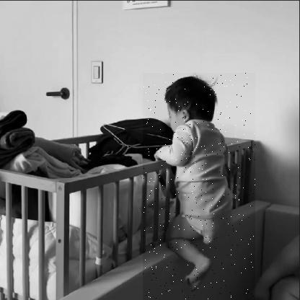

1 baby_bed_climbing3_mov-0_jpg.rf.29027114a3a96


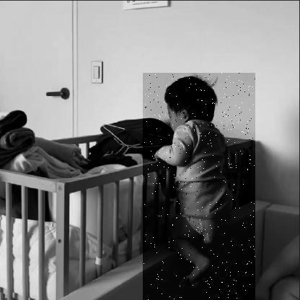

2 baby_bed_climbing3_mov-0_jpg.rf.5139f34a2d19a


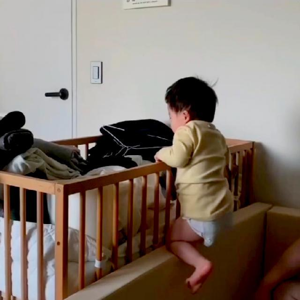

3 baby_bed_climbing3_mov-0_jpg.rf.841506af4a5bb


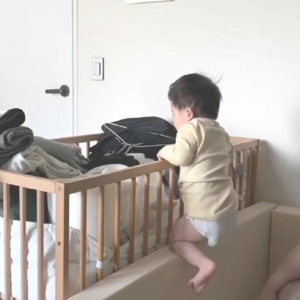

4 baby_bed_climbing3_mov-0_jpg.rf.fb2c9c8e3963d


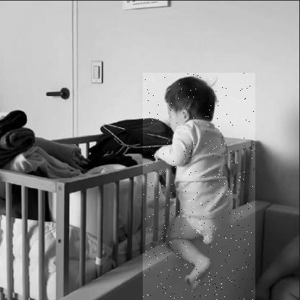

5 baby_bed_climbing3_mov-2_jpg.rf.1b5d7cbc6e718


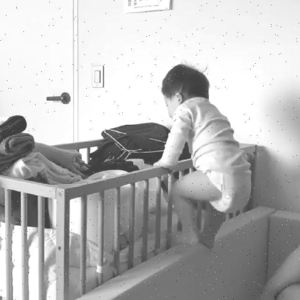

6 baby_bed_climbing3_mov-2_jpg.rf.82af313609c18


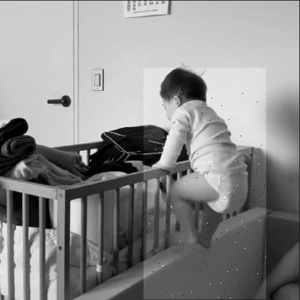

7 baby_bed_climbing3_mov-2_jpg.rf.9e152db19e294


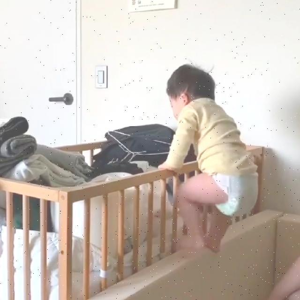

8 baby_bed_climbing3_mov-2_jpg.rf.a4ba2c466c42b


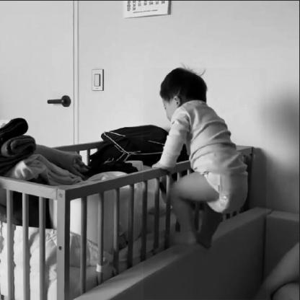

9 baby_bed_climbing3_mov-2_jpg.rf.d35c9c61be410


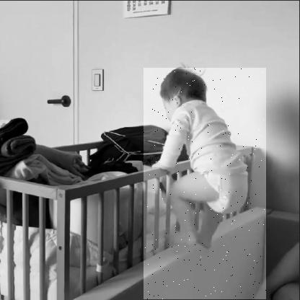

10 baby_bed_climbing3_mov-7_jpg.rf.66102b2678c87


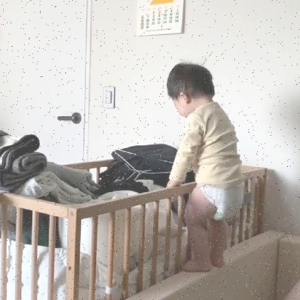

11 baby_bed_climbing3_mov-7_jpg.rf.c7d3a86373976


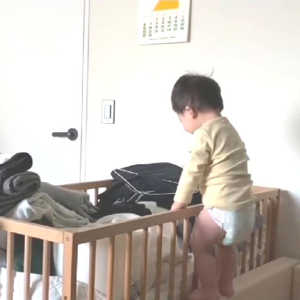

12 baby_bed_climbing3_mov-7_jpg.rf.8623892318b0d


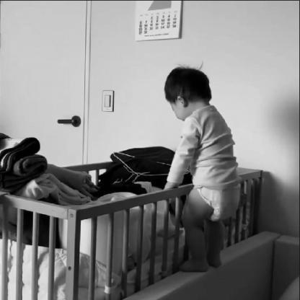

13 baby_bed_climbing3_mov-9_jpg.rf.8dc89b9dccdfa


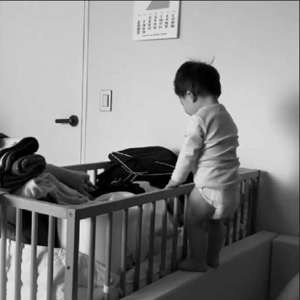

14 baby_bed_climbing3_mov-9_jpg.rf.44a6b6e591b53


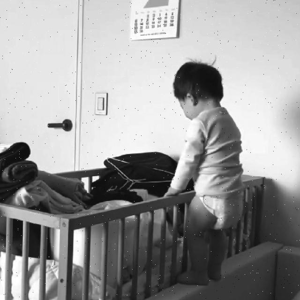

15 baby_bed_climbing3_mov-9_jpg.rf.ac07ae0de944d


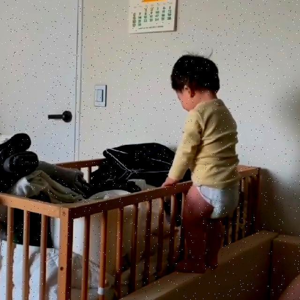

16 baby_bed_climbing3_mov-11_jpg.rf.1d864adc4a8b


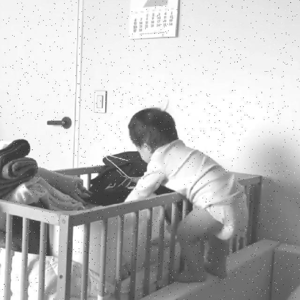

17 baby_bed_climbing3_mov-11_jpg.rf.b38fdd3c4371


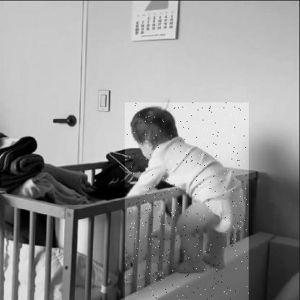

18 baby_bed_climbing3_mov-11_jpg.rf.baa77117c9d7


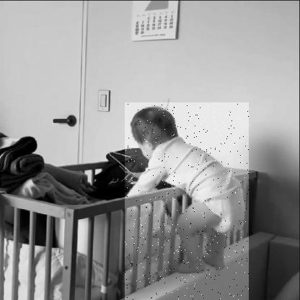

19 baby_bed_climbing3_mov-11_jpg.rf.da6a2cdbb431


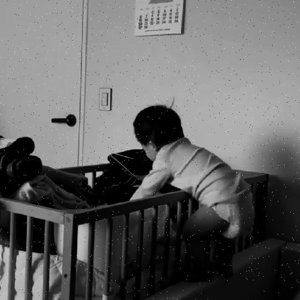

20 baby_bed_climbing3_mov-11_jpg.rf.ece56c34ee8f


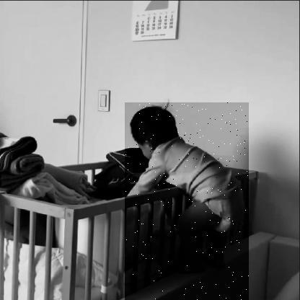

21 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


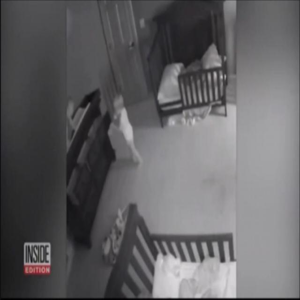

22 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


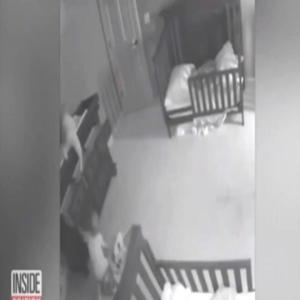

23 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


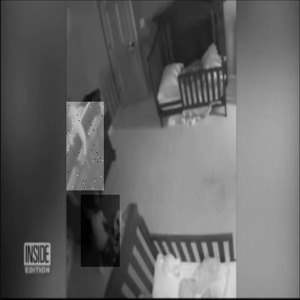

24 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


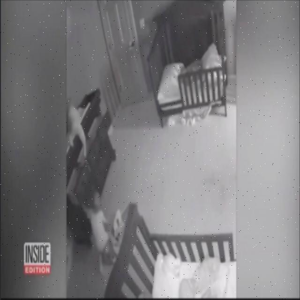

25 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


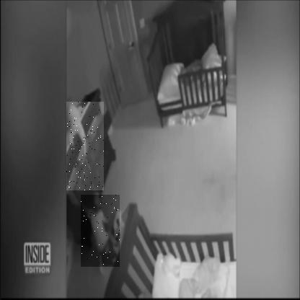

26 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


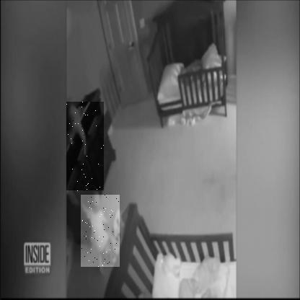

27 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


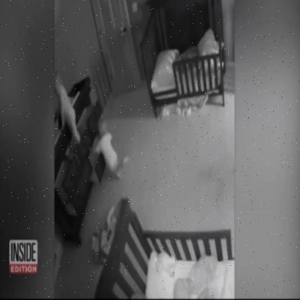

28 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


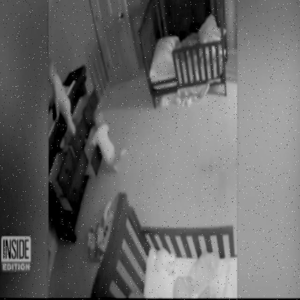

29 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


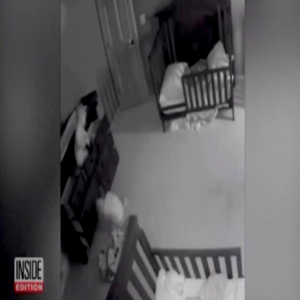

30 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


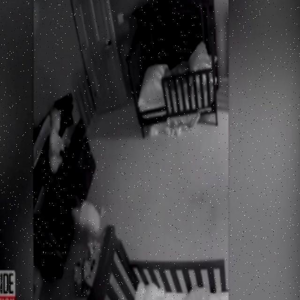

31 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


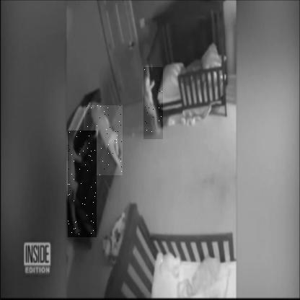

32 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


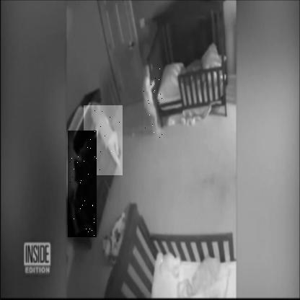

33 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


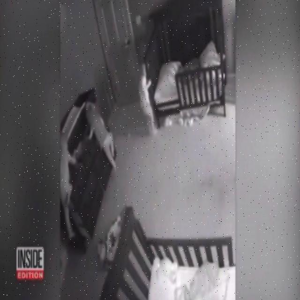

34 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


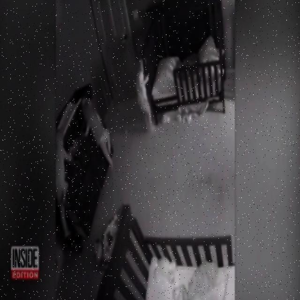

35 Wondershare_Filmora_2022-10-20_01-15-36_Adobe


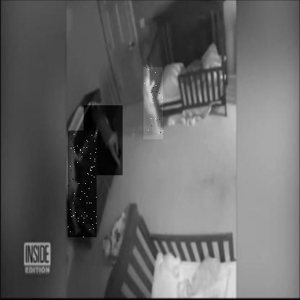

36 babyfallings2_mp4-212_jpg.rf.10e544a9221d7e6d


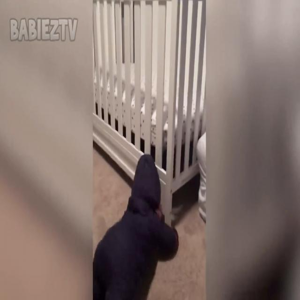

37 babyfallings2_mp4-212_jpg.rf.8bc37d722ccb4f36


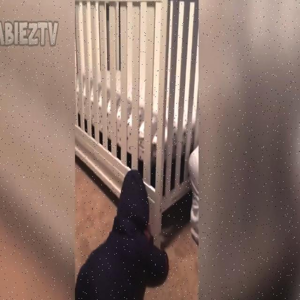

In [9]:
from PIL import Image
from IPython.display import display

wanted = [
    'baby_bed_climbing3_mov-0_jpg',
    'baby_bed_climbing3_mov-2_jpg',
    'baby_bed_climbing3_mov-7_jpg',
    'baby_bed_climbing3_mov-9_jpg',
    'baby_bed_climbing3_mov-11_jpg',
    'Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-2_jpg',
    'Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-4_jpg',
    'Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-7_jpg',
    'Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-10_jpg',
    'Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-12_jpg',
    'babyfallings2_mp4-212_jpg',
]

found = []
for name in wanted:
    copies = 0
    for path in sorted(vtar_images):
        if os.path.basename(path).startswith(name + '.'):
            found.append(path)
            copies += 1
    print(copies, 'copies of', name)

print()
print('Total copies found:', len(found))

number = 0
for path in found:
    print(number, os.path.basename(path)[:45])
    img = Image.open(path)
    img.thumbnail((300, 300))
    display(img)
    number += 1

In [10]:
import shutil

keep = [2, 7, 11, 17, 21, 26, 27, 29, 33, 36]

left_folder = '/content/drive/MyDrive/crib_sentry_v2/left_the_crib_test'
os.makedirs(left_folder, exist_ok=True)

left_images = []
for number in keep:
    new_path = left_folder + '/' + os.path.basename(found[number])
    shutil.copy(found[number], new_path)
    left_images.append(new_path)

print('Images in the test folder:', len(left_images))
for path in left_images:
    print(os.path.basename(path)[:60])

Images in the test folder: 10
baby_bed_climbing3_mov-0_jpg.rf.5139f34a2d19a2ba2d0f5af0e0e7
baby_bed_climbing3_mov-2_jpg.rf.9e152db19e2940d7a6a4d491ef3b
baby_bed_climbing3_mov-7_jpg.rf.c7d3a8637397617eeeb3f94425c6
baby_bed_climbing3_mov-11_jpg.rf.b38fdd3c437160b736556b237b6
Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-2_j
Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-4_j
Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-7_j
Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-10_
Wondershare_Filmora_2022-10-20_01-15-36_AdobeExpress_mp4-12_
babyfallings2_mp4-212_jpg.rf.10e544a9221d7e6d385c2b35801ea49


Test images: 24
0 125_jpg.rf.b8de7969f


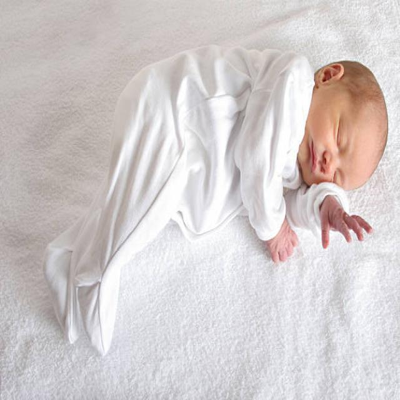

1 138_jpg.rf.25abb3a8b


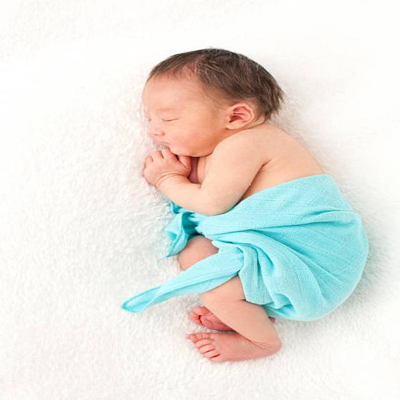

2 147_jpg.rf.e1014d571


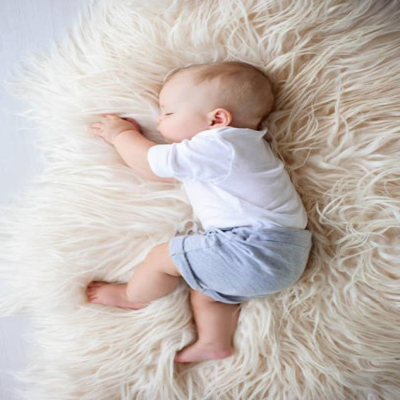

3 153_jpg.rf.38a1b9b2a


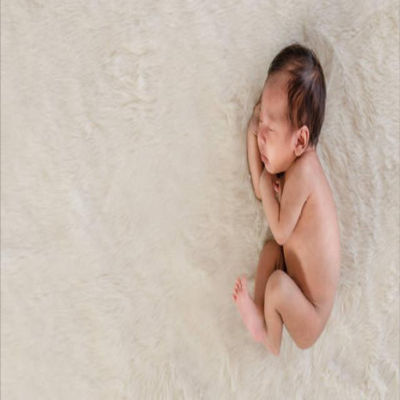

4 18_jpg.rf.d8fb3c33ae


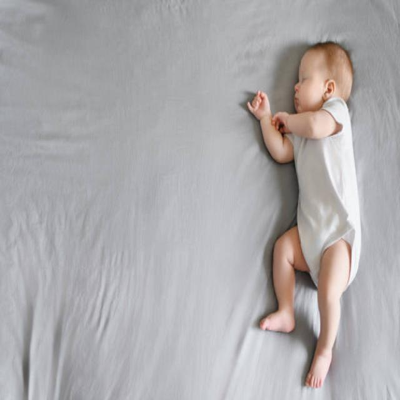

5 240_F_167115185_EYt0


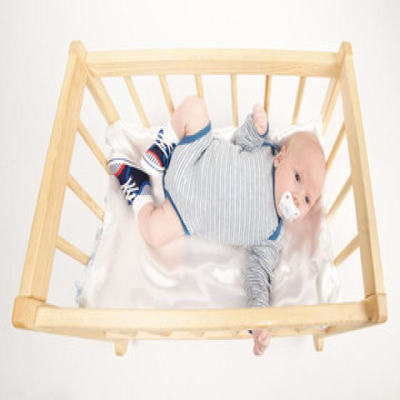

6 240_F_167115291_KJVJ


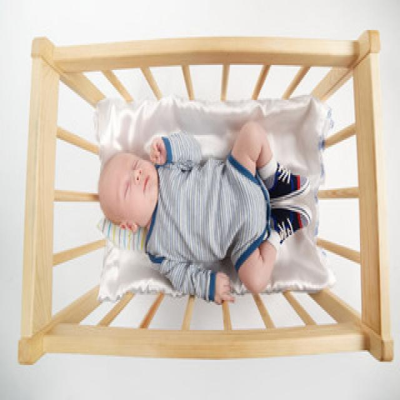

7 240_F_338108473_aS4Y


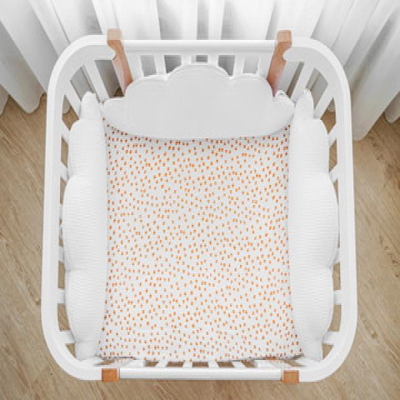

8 240_F_37985105_5Mxqi


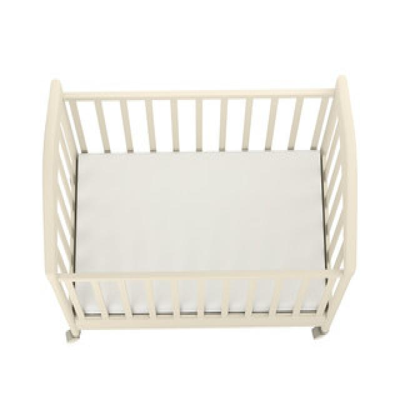

9 240_F_447295527_JPLN


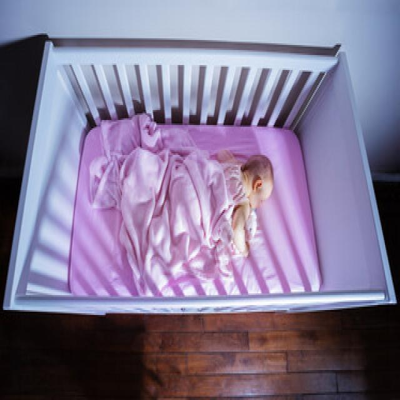

10 240_F_797831921_q0pd


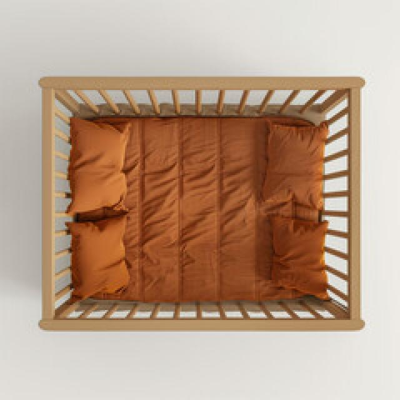

11 52_jpg.rf.e6a3ff3a56


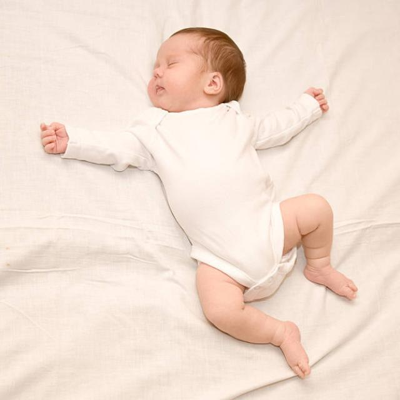

12 57_jpg.rf.9d4e0ad88e


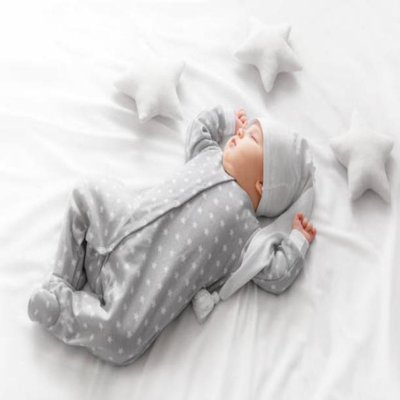

13 65_jpg.rf.ac50a0cad3


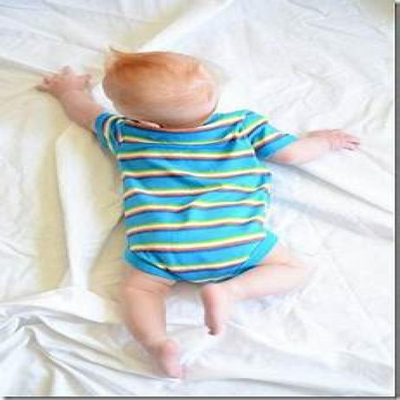

14 71_jpg.rf.4e1646fb33


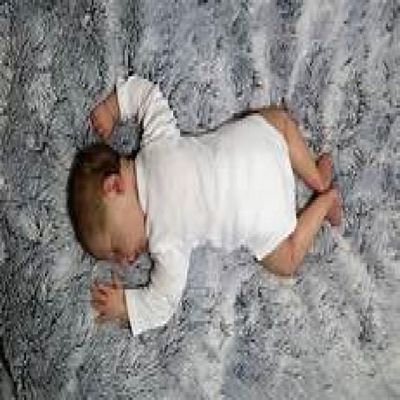

15 84_jpg.rf.b5cbaca16f


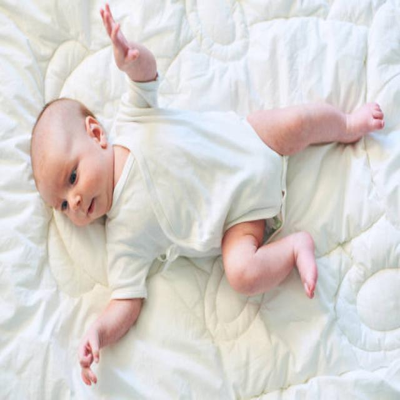

16 8_jpg.rf.71c3f94df28


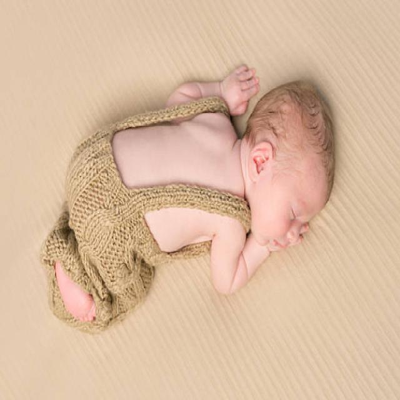

17 gettyimages-11514398


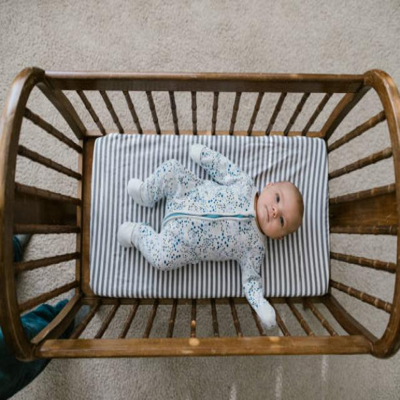

18 gettyimages-13665795


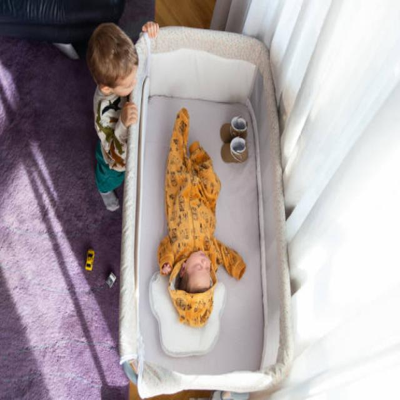

19 il_570xN-3352902549_


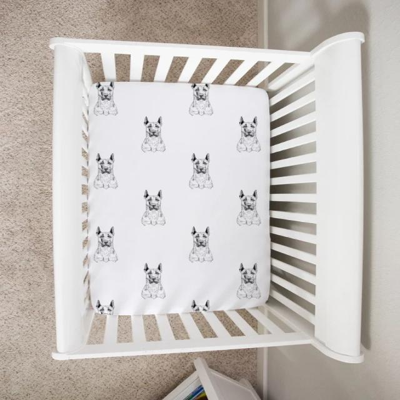

20 images-42-_jpg.rf.7c


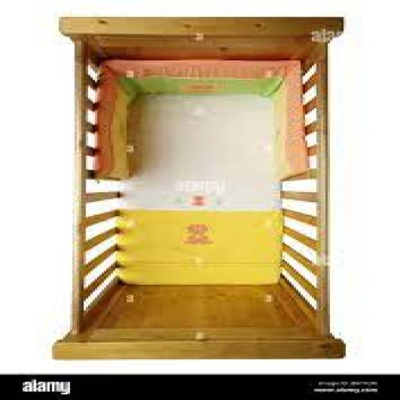

21 images-45-_jpg.rf.99


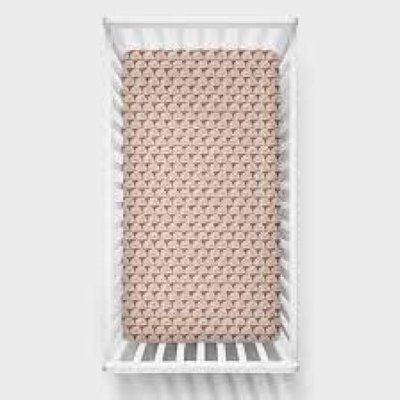

22 images-47-_jpg.rf.e9


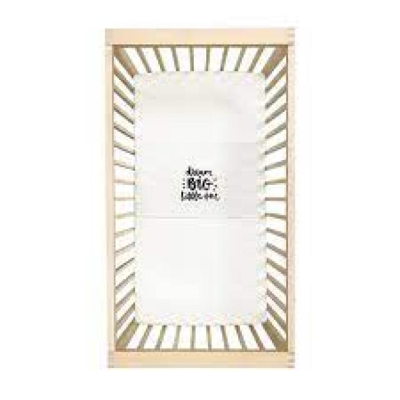

23 images-54-_jpg.rf.b4


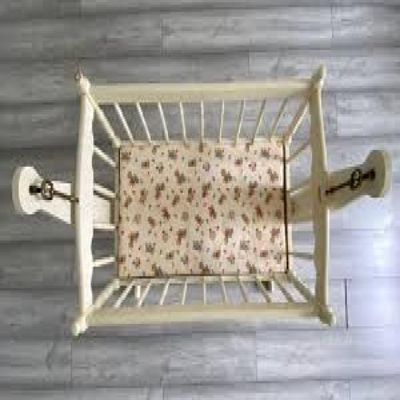

In [11]:
test_images = sorted(glob.glob(dataset.location + '/test/images/*'))
print('Test images:', len(test_images))

number = 0
for path in test_images:
    print(number, os.path.basename(path)[:20])
    img = Image.open(path)
    img.thumbnail((400, 400))
    display(img)
    number += 1

In [12]:
# c = all clear, l = left the crib, n = not visible, h = hazard present
letters = [
    'n',  # 0
    'n',  # 1
    'n',  # 2
    'n',  # 3
    'n',  # 4
    'c',  # 5
    'c',  # 6
    'n',  # 7
    'n',  # 8
    'h',  # 9
    'h',  # 10
    'n',  # 11
    'n',  # 12
    'n',  # 13
    'n',  # 14
    'n',  # 15
    'n',  # 16
    'c',  # 17
    'c',  # 18
    'n',  # 19
    'n',  # 20
    'n',  # 21
    'n',  # 22
    'n',  # 23
]

names = {'c': 'all clear', 'l': 'left the crib', 'n': 'not visible', 'h': 'hazard present'}

tags = []
for letter in letters:
    tags.append(names[letter])

counts = {}
for tag in tags:
    counts[tag] = counts.get(tag, 0) + 1
print('Tags:', len(tags))
for tag, n in counts.items():
    print(tag, n)

Tags: 24
not visible 18
all clear 4
hazard present 2


In [13]:
import time

def measure(images, correct_tags, title):
    correct = 0
    total_time = 0
    print(title)
    print('number | image | my tag | system alert | result')
    for number in range(len(images)):
        start = time.time()
        alert = get_alert(images[number])
        total_time += time.time() - start

        if alert == correct_tags[number]:
            result = 'correct'
            correct += 1
        else:
            result = 'WRONG'
        print(number, '|', os.path.basename(images[number])[:20], '|',
              correct_tags[number], '|', alert, '|', result)

    print()
    print('Correct:', correct, 'of', len(images))
    print('Alert accuracy:', round(100 * correct / len(images), 1), '%')
    print('Average time per image:', round(total_time / len(images), 3), 'seconds')
    print()

measure(test_images, tags, 'Baby in Crib test images')

left_tags = ['left the crib'] * len(left_images)
measure(left_images, left_tags, 'Left the crib test images')

Baby in Crib test images
number | image | my tag | system alert | result
0 | 125_jpg.rf.b8de7969f | not visible | not visible | correct
1 | 138_jpg.rf.25abb3a8b | not visible | not visible | correct
2 | 147_jpg.rf.e1014d571 | not visible | not visible | correct
3 | 153_jpg.rf.38a1b9b2a | not visible | not visible | correct
4 | 18_jpg.rf.d8fb3c33ae | not visible | all clear | WRONG
5 | 240_F_167115185_EYt0 | all clear | all clear | correct
6 | 240_F_167115291_KJVJ | all clear | all clear | correct
7 | 240_F_338108473_aS4Y | not visible | not visible | correct
8 | 240_F_37985105_5Mxqi | not visible | not visible | correct
9 | 240_F_447295527_JPLN | hazard present | hazard present | correct
10 | 240_F_797831921_q0pd | hazard present | hazard present | correct
11 | 52_jpg.rf.e6a3ff3a56 | not visible | not visible | correct
12 | 57_jpg.rf.9d4e0ad88e | not visible | not visible | correct
13 | 65_jpg.rf.ac50a0cad3 | not visible | hazard present | WRONG
14 | 71_jpg.rf.4e1646fb33 | not visible 

4 | my tag: not visible | system: all clear
    Child 0.81
    Crib 0.47


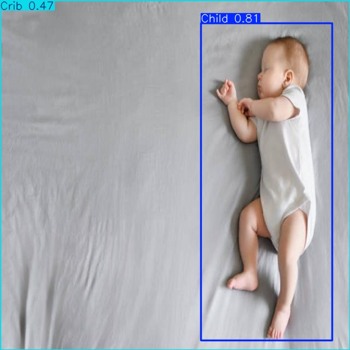

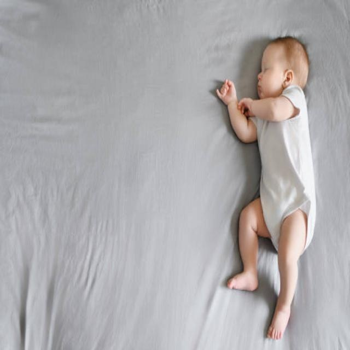

13 | my tag: not visible | system: hazard present
    Crib 0.34
    Child 0.31


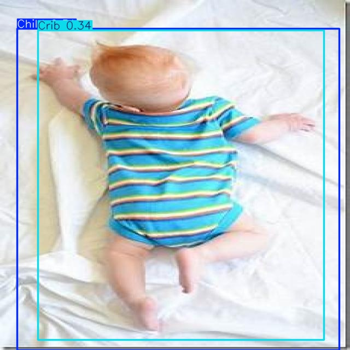

    hard-toy 0.87


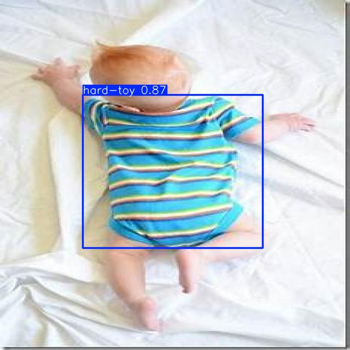

15 | my tag: not visible | system: hazard present
    Child 0.83
    Crib 0.33


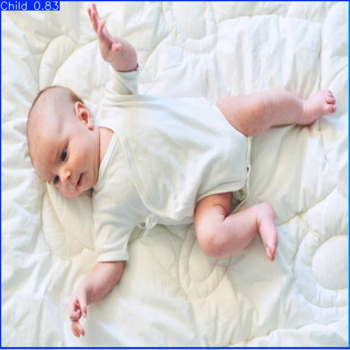

    blanket 0.55


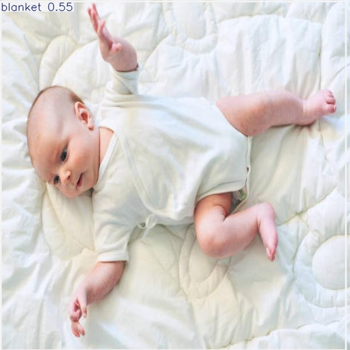

17 | my tag: all clear | system: not visible
    Crib 0.95


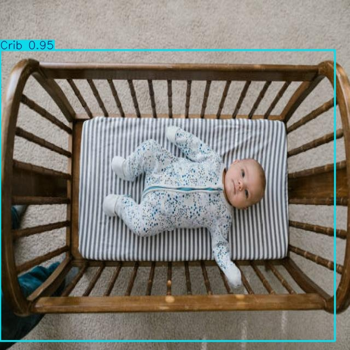

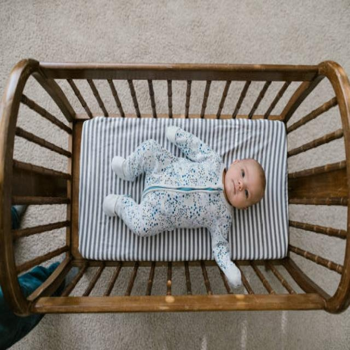

19 | my tag: not visible | system: hazard present
    Crib 0.89


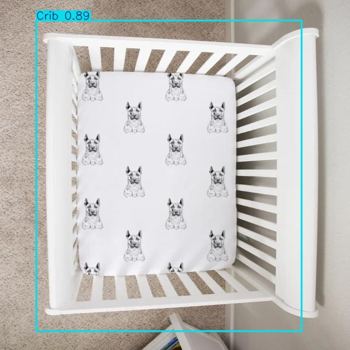

    blanket 0.45


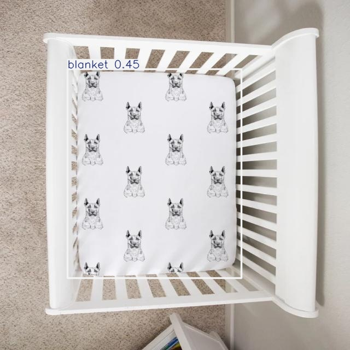

21 | my tag: not visible | system: hazard present
    Crib 0.97


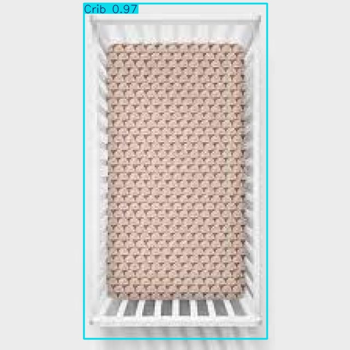

    blanket 0.64


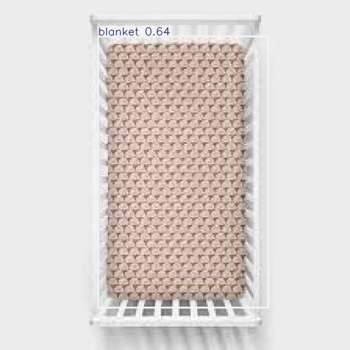

0 | my tag: left the crib | system: all clear
    Crib 0.58
    Child 0.26


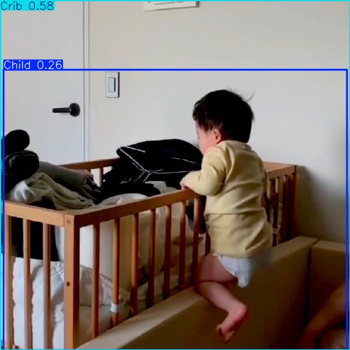

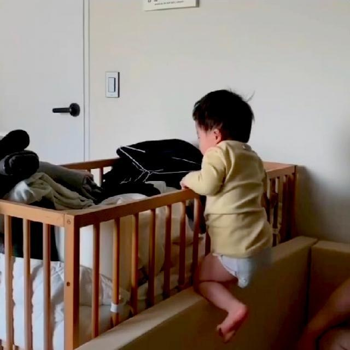

1 | my tag: left the crib | system: not visible
    Crib 0.56


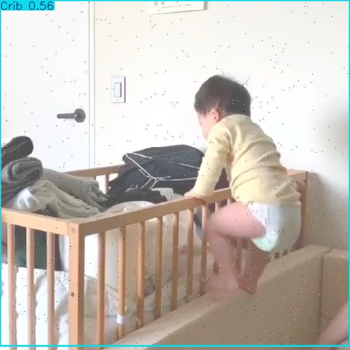

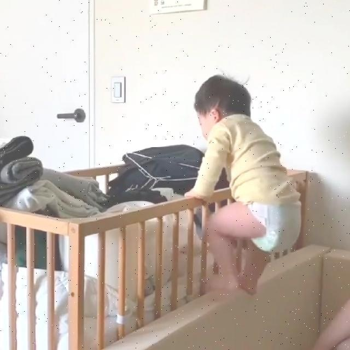

2 | my tag: left the crib | system: not visible
    Crib 0.74
    Crib 0.35


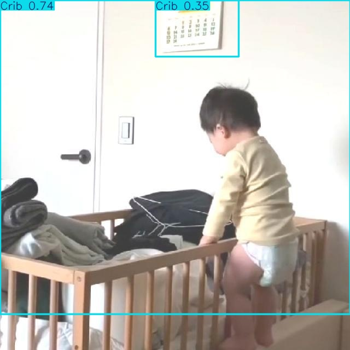

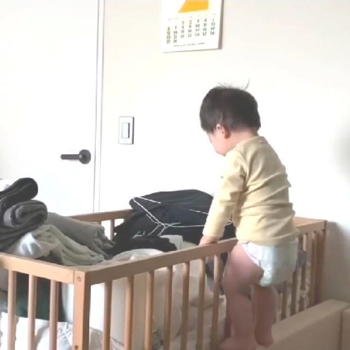

3 | my tag: left the crib | system: hazard present
    Crib 0.53
    Child 0.34
    Crib 0.29
    Child 0.28


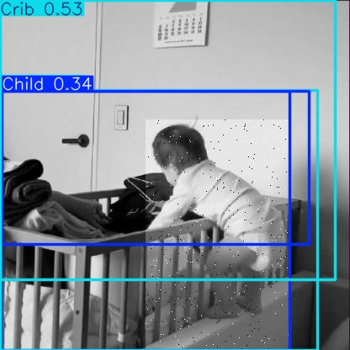

    blanket 0.31


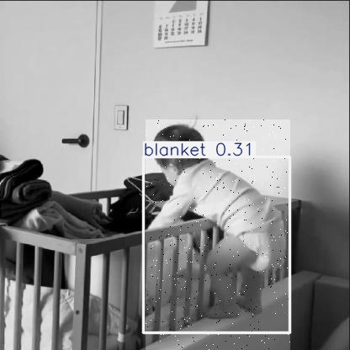

4 | my tag: left the crib | system: hazard present
    Child 0.5
    Crib 0.31


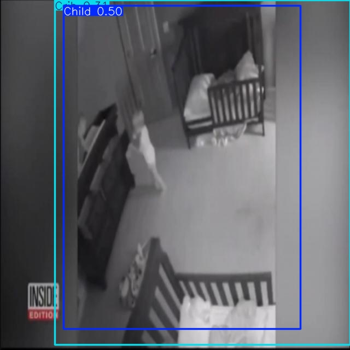

    hard-toy 0.79
    hard-toy 0.35


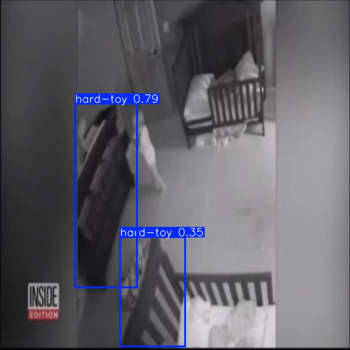

5 | my tag: left the crib | system: hazard present
    Crib 0.31


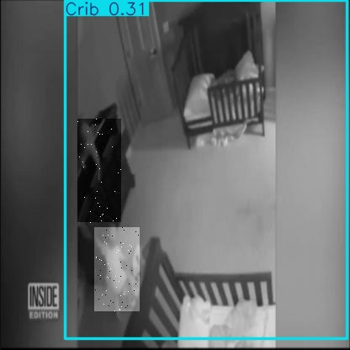

    hard-toy 0.42


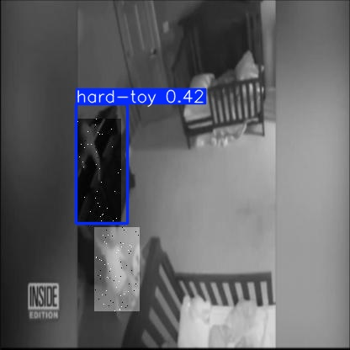

6 | my tag: left the crib | system: hazard present
    Crib 0.53
    Child 0.44


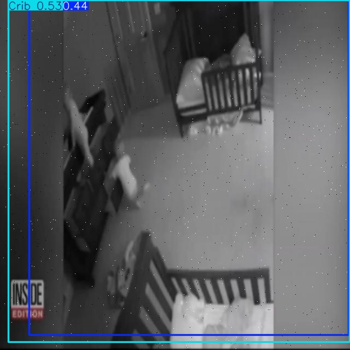

    blanket 0.46
    blanket 0.36


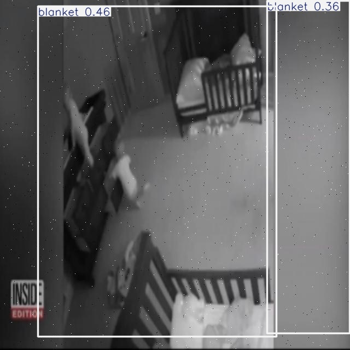

7 | my tag: left the crib | system: hazard present
    Child 0.68
    Crib 0.27


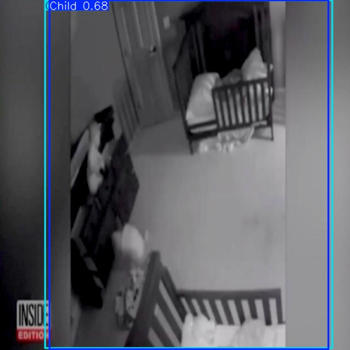

    hard-toy 0.55


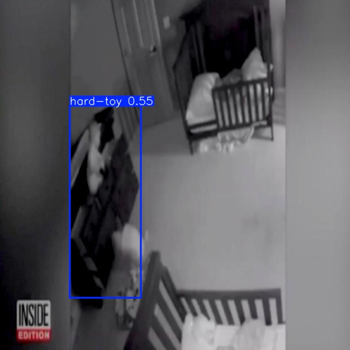

8 | my tag: left the crib | system: hazard present
    Crib 0.66


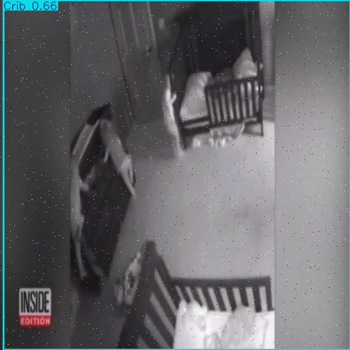

    blanket 0.83


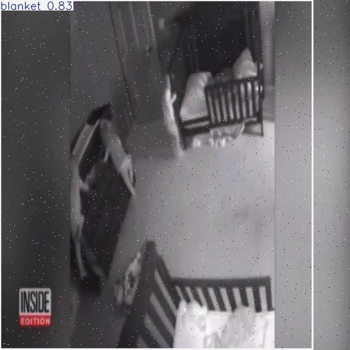

9 | my tag: left the crib | system: hazard present
    Crib 0.48
    Child 0.29


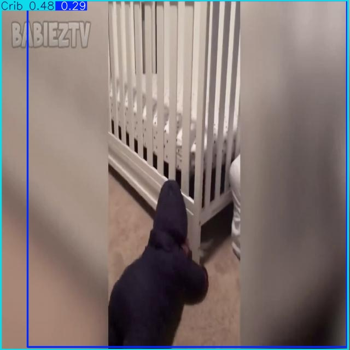

    hard-toy 0.53


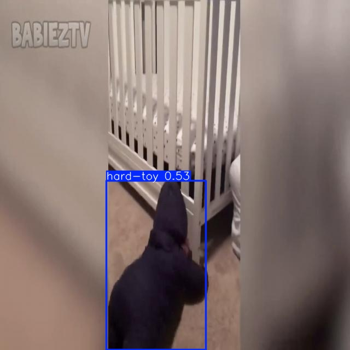

In [14]:
def show_boxes(images, correct_tags, numbers):
    for number in numbers:
        path = images[number]
        print(number, '| my tag:', correct_tags[number], '| system:', get_alert(path))
        for model in [child_crib, hazards]:
            result = model(path, verbose=False)[0]
            for box in result.boxes:
                print('   ', model.names[int(box.cls[0])], round(float(box.conf[0]), 2))
            result.save(filename='/content/boxed.jpg')
            small = Image.open('/content/boxed.jpg')
            small.thumbnail((350, 350))
            display(small)

show_boxes(test_images, tags, [4, 13, 15, 17, 19, 21])
show_boxes(left_images, left_tags, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## First measurement
- Alert accuracy on the 24 test images: 75.0% (18 of 24). My target was 85% or more.
- Time for each image on the T4 GPU: 0.056 seconds. My target was less than 1 second.
- "Left the crib" on 10 images from a different dataset: 0 of 10 correct.

What went wrong:
- The crib detector drew a Crib box on the full frame in photos with no crib and in photos of real rooms.
- The child detector did not find the baby in image 17 and was weak in the real room photos.
- The hazard detector put a blanket box on fitted sheets and a toy box on clothes and furniture.

The training photos are studio photos, and the photos that failed are real rooms or have no crib.

My Blueprint named this risk, and it was greater than I expected.